In [124]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use('./deeplearning.mplstyle')
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays


X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])


# data is stored in numpy array/matrix
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")



X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]
w_init shape: (4,), b_init type: <class 'float'>


In [125]:
def predict_single_loop(x, w, b):
    """
    single sample prediction using linear regression
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters    
      b (scalar):  model parameter     
      
    Returns:
      p (scalar):  prediction
    """
    n = x.shape[0]
    p_wb = 0

    for i in range(n):
        p_wb_i =  x[i] * w[i]
        p_wb = p_wb + p_wb_i
        
    p_wb = p_wb + b 

    return p_wb


x_vector = X_train[0,:]

f_wb = predict_single_loop(x_vector, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")
print(f"Predicted Value is {f_wb} vs actual Value was {y_train[0]}")


f_wb shape (), prediction: 459.9999976194083
Predicted Value is 459.9999976194083 vs actual Value was 460


In [126]:
def predict_using_vectorized_method(x, w, b):
    """
    single sample prediction using dot product i.e vectorised value using linear regression

    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters   
      b (scalar):             model parameter 
      
    Returns:
      p (scalar):  prediction
    """

    # below is code is internally multiplity each value of x and w within same position and resulting the sum of all the multiplication
     
    p_wb =  np.dot(x, w) + b
    return p_wb

X_vector = X_train[1, :]

f_wb_vectorized = predict_using_vectorized_method(X_vector, w_init, b_init)
print(f"f_wb shape {f_wb_vectorized.shape}, prediction: {f_wb_vectorized}")
print(f"Predicted Value is {f_wb_vectorized} vs actual Value was {y_train[1]}")


f_wb shape (), prediction: 231.9999983694081
Predicted Value is 231.9999983694081 vs actual Value was 232


In [127]:
def compute_cost(x, y, w, b):
    """"
    Computing Cost Function for multiple linear regression i.e calculating the cost for multiple feature 
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost

    """

    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(x[i], w) + b

        cost  = cost + (f_wb_i - y[i])**2
    cost = cost / (2 * m)

    return cost

b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])


cost  = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


In [129]:
# Function to find the Gradient means the derivatives of w and b 
# i.e tells how much to moves as in magnitude 

def compute_gradient(X, y, w, b):
    """
    Compute the Gradient for linear regression
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      gradient (scalar): dj_dw, dj_db
            
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b. 
    """

    m, n = X.shape
    dj_dw = np.zeros((n, ))
    dj_db = 0.0
    for i in range(m):
        actual_vs_predict_error = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + actual_vs_predict_error * X[i, j]
        
        dj_db = dj_db + actual_vs_predict_error
    dj_db = dj_db / m
    dj_dw = dj_dw / m 

    return dj_dw, dj_db

#Compute and display gradient 
tmp_dj_dw, tmp_dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')




dj_db at initial w,b: -1.6739251501955248e-06
dj_dw at initial w,b: 
 [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


In [172]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradint_function, alpha, num_iters):
    """
    Performs batch gradient descent to learn or find optimal w and b. Updates w and b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db =  gradint_function(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            J_history.append(cost_function(X, y, w, b))
        
        
        if i% math.ceil(num_iters / 10) == 0 :
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w, b, J_history


w_intial = np.zeros_like(w_init)
b_initial = 0.0
alpha = 5.0e-7
num_itterations = 1000

w_final, b_final, j_hist = gradient_descent(X_train, y_train, w_intial, b_initial,
             compute_cost, compute_gradient, alpha, num_itterations)


print(f"b,w found by gradient descent: {b_final:0.4f},{w_final} ")


Iteration    0: Cost  2529.46   
Iteration  100: Cost   695.99   
Iteration  200: Cost   694.92   
Iteration  300: Cost   693.86   
Iteration  400: Cost   692.81   
Iteration  500: Cost   691.77   
Iteration  600: Cost   690.73   
Iteration  700: Cost   689.71   
Iteration  800: Cost   688.70   
Iteration  900: Cost   687.69   
b,w found by gradient descent: -0.0022,[ 0.2   0.   -0.01 -0.07] 


In [173]:
# Compute Linear regression to predict best fit line

def predict_using_linear_regression(X, y, w, b):

    m = X.shape[0] # NUmber of sample data i.e row
    
    y_predict = []
    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        y_predict.append(f_wb)
    
    return y_predict

y_prect = predict_using_linear_regression(X_train, y_train, w_final, b_final)
y_prect

for i in range(X_train.shape[0]):
    print(f"prediction: {y_prect[i]}, target value: {y_train[i]}")
    

prediction: 426.18530497189204, target value: 460
prediction: 286.1674720078562, target value: 232
prediction: 171.46763087132317, target value: 178


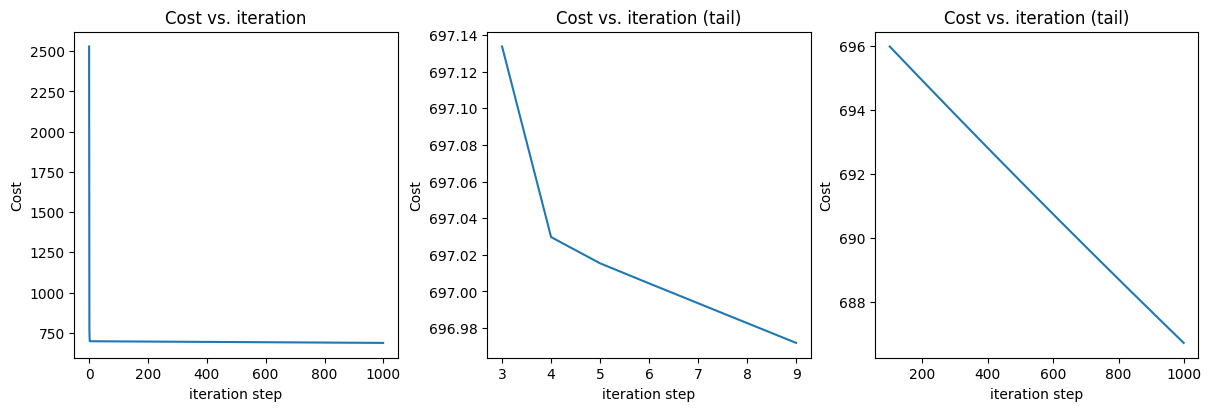

In [210]:
# plot cost versus iteration  
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,  constrained_layout=True, figsize=(12, 4))
ax1.plot(j_hist)
ax2.plot( 3+ np.arange(len(j_hist[3:10])), j_hist[3:10])
ax3.plot(100 + np.arange(len(j_hist[100:])), j_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)");  ax3.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost')                    ;  ax3.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step')          ;  ax3.set_xlabel('iteration step') 
plt.show()